# Ingesting Data & Creating Tables to Store in PostgreSQL DB

In [ ]:
import pandas as pd
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT

In [1]:
bestsellers = pd.read_csv('/Users/hanah/Documents/GitHub/literary/notebooks/bestsellers_clean.csv')
critics = pd.read_csv('/Users/hanah/Documents/GitHub/literary/notebooks/critics_clean.csv')

In [2]:
# Connect to the default 'postgres' database
con = psycopg2.connect(dbname='postgres', user='postgres', host='localhost', password='123456')
con.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT) # Required to create DBs
cur = con.cursor()

# Create your new database
cur.execute('CREATE DATABASE nytimes')

DuplicateDatabase: database "nytimes" already exists


In [3]:
# Step 1: Define the connection parameters
def get_connection():
    return psycopg2.connect(
        host = 'localhost',
        database = 'bestsellers',
        user = 'postgres',
        password = '123456'
    )


# Step 2: Establish the connection
conn = get_connection()
cur = conn.cursor()

# Step 3: Create the Tables (Dropping old ones to avoid "already exists" errors)
cur.execute("DROP TABLE IF EXISTS bestsellers; DROP TABLE IF EXISTS critics;")

cur.execute("""
    CREATE TABLE bestsellers (
        title TEXT, 
        author TEXT, 
        publisher TEXT, 
        description TEXT, 
        rank INT,
        weeks_on_list INT,
        primary_isbn13 BIGINT,
        list_name TEXT,
        list_date TIMESTAMP
    )
""")

cur.execute("""
    CREATE TABLE critics (
        headline TEXT,
        byline TEXT,
        section_name TEXT,
        pub_date TIMESTAMP,
        abstract TEXT,
        web_url TEXT,
        keywords TEXT
    )
""")

# Step 4: Import File 1 (Using copy_expert to handle commas inside quotes)
with open('/Users/hanah/Documents/GitHub/literary/notebooks/bestsellers_clean.csv', 'r') as f:
    cur.copy_expert("COPY bestsellers FROM STDIN WITH (FORMAT CSV, HEADER)", f)

# Step 5: Import File 2
with open('/Users/hanah/Documents/GitHub/literary/notebooks/critics_clean.csv', 'r') as f:
    cur.copy_expert("COPY critics FROM STDIN WITH (FORMAT CSV, HEADER)", f)

# Step 6: Save changes
    conn.commit()

# Running SQL Queries

#### Query 1: Top 10 Longest Running Best Sellers

In [4]:
query_1 = '''
SELECT 
    title, 
    author, 
    MAX(weeks_on_list) as total_weeks,
    MIN(rank) as best_rank
FROM bestsellers
GROUP BY title, author
ORDER BY total_weeks DESC
LIMIT 10;
'''
cur.execute(query_1)
results = cur.fetchall()
print(results)

[('EDUCATED', 'Tara Westover', 138, 1), ('WHERE THE CRAWDADS SING', 'Delia Owens', 134, 1), ('ALL THE LIGHT WE CANNOT SEE', 'Anthony Doerr', 134, 1), ('OUTLIVE', 'Peter Attia with Bill Gifford', 122, 1), ('BECOMING', 'Michelle Obama', 106, 1), ('THE MIDNIGHT LIBRARY', 'Matt Haig', 106, 1), ('BETWEEN THE WORLD AND ME', 'Ta-Nehisi Coates', 101, 1), ('UNTAMED', 'Glennon Doyle', 101, 1), ('LESSONS IN CHEMISTRY', 'Bonnie Garmus', 99, 1), ('GREENLIGHTS', 'Matthew McConaughey', 98, 1)]


#### Query 2: Authors that have the most amount of books on the best sellers list

In [5]:
query_2 = '''SELECT 
    author, 
    COUNT(DISTINCT title) as unique_bestsellers,
    AVG(weeks_on_list)::NUMERIC(10,2) as avg_weeks_per_book
FROM bestsellers
GROUP BY author
HAVING COUNT(DISTINCT title) > 1
ORDER BY unique_bestsellers DESC
LIMIT 10;
'''
cur.execute(query_2)
results = cur.fetchall()
print(results)

[('Danielle Steel', 68, Decimal('2.10')), ('David Baldacci', 23, Decimal('5.07')), ('Stuart Woods', 22, Decimal('1.47')), ('Nora Roberts', 19, Decimal('2.74')), ('Debbie Macomber', 18, Decimal('1.84')), ('J.D. Robb', 17, Decimal('2.12')), ('John Sandford', 16, Decimal('2.73')), ('John Grisham', 15, Decimal('9.64')), ('Elin Hilderbrand', 15, Decimal('4.80')), ('Douglas Preston and Lincoln Child', 14, Decimal('1.78'))]


#### Query 3: Rank for Hardcover Fiction Books

In [9]:
query_3 = '''
SELECT DISTINCT
    title,
    author,
    FIRST_VALUE(rank) OVER (PARTITION BY title ORDER BY list_date ASC) as starting_rank,
    LAST_VALUE(rank) OVER (PARTITION BY title ORDER BY list_date ASC 
        ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) as current_rank,
    COUNT(*) OVER (PARTITION BY title) as times_on_list
FROM bestsellers
WHERE list_name = 'hardcover-fiction'
ORDER BY times_on_list DESC
LIMIT 20;
'''

cur.execute(query_3)
results = cur.fetchall()

for row in results:
    print(f"Book: {row[0]} | Started at: {row[2]} | Current: {row[3]} | Weeks: {row[4]}")

Book: WHERE THE CRAWDADS SING | Started at: 9 | Current: 15 | Weeks: 134
Book: THE MIDNIGHT LIBRARY | Started at: 13 | Current: 12 | Weeks: 107
Book: LESSONS IN CHEMISTRY | Started at: 14 | Current: 13 | Weeks: 99
Book: FOURTH WING | Started at: 2 | Current: 13 | Weeks: 98
Book: IRON FLAME | Started at: 1 | Current: 14 | Weeks: 82
Book: DEMON COPPERHEAD | Started at: 2 | Current: 15 | Weeks: 70
Book: THE LAST THING HE TOLD ME | Started at: 1 | Current: 15 | Weeks: 66
Book: THE WOMEN | Started at: 1 | Current: 15 | Weeks: 66
Book: A GENTLEMAN IN MOSCOW | Started at: 8 | Current: 10 | Weeks: 64
Book: REMARKABLY BRIGHT CREATURES | Started at: 15 | Current: 14 | Weeks: 64
Book: ALL THE LIGHT WE CANNOT SEE | Started at: 5 | Current: 20 | Weeks: 58
Book: THE SILENT PATIENT | Started at: 1 | Current: 11 | Weeks: 56
Book: BEFORE WE WERE YOURS | Started at: 12 | Current: 13 | Weeks: 54
Book: JAMES | Started at: 4 | Current: 15 | Weeks: 52
Book: THE NIGHTINGALE | Started at: 13 | Current: 11 | W

#### Query 4: Most successful authors – How often they have appeared on the best sellers list

In [10]:
query_4 = """
SELECT author, COUNT(*) as appearances
FROM bestsellers
GROUP BY author
ORDER BY appearances DESC
LIMIT 10
"""

df_trends = pd.read_sql_query(query, conn)
df_trends

/var/folders/kq/4pxsh14534gfd6j4zw3d9f0h0000gq/T/ipykernel_5176/3471865681.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trends = pd.read_sql_query(query, conn)


,author,appearances
0,John Grisham,246
1,Rebecca Yarros,220
2,David Baldacci,198
3,Danielle Steel,196
4,Stephen King,187
5,Kristin Hannah,166
6,Delia Owens,134
7,Nicholas Sparks,122
8,Bill O'Reilly and Martin Dugard,121
9,Matt Haig,112


#### Query 5: How many weeks a specific book has been on the chart + how many reviews it received

In [11]:
query_5 = """
SELECT 
    b.title, 
    b.author, 
    MAX(b.weeks_on_list) as max_weeks,
    COUNT(c.headline) as review_count
FROM bestsellers b
LEFT JOIN critics c ON LOWER(b.title) = LOWER(c.headline)
GROUP BY b.title, b.author
HAVING COUNT(c.headline) > 0
ORDER BY review_count DESC, max_weeks DESC;
"""

df_analysis = pd.read_sql_query(query_correlation, conn)
df_analysis.head(10)

/var/folders/kq/4pxsh14534gfd6j4zw3d9f0h0000gq/T/ipykernel_5176/1262747499.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_analysis = pd.read_sql_query(query_correlation, conn)


,title,author,max_weeks,review_count
0,DREAMLAND,Nicholas Sparks,16,32
1,SPARRING PARTNERS,John Grisham,13,26
2,WISH YOU WERE HERE,Jodi Picoult,13,26
3,LOST AND FOUND,Danielle Steel,4,16
4,SLEEPING BEAUTIES,Stephen King and Owen King,14,14
5,PREQUEL,Rachel Maddow,17,12
6,WHAT HAPPENED,Hillary Clinton,16,12
7,RUSSIAN ROULETTE,Michael Isikoff and David Corn,8,12
8,THE AWAKENING,Nora Roberts,6,12
9,SWING TIME,Zadie Smith,2,12


In [13]:
query_4 = '''SELECT 
    publisher, 
    COUNT(DISTINCT title) as total_unique_books,
    SUM(weeks_on_list) as total_shelf_life
FROM bestsellers
GROUP BY publisher
ORDER BY total_shelf_life DESC
LIMIT 10;
'''
cur.execute(query_3)
results = cur.fetchall()
print(results)

[('WHERE THE CRAWDADS SING', 'Delia Owens', 9, 15, 134), ('THE MIDNIGHT LIBRARY', 'Matt Haig', 13, 12, 107), ('LESSONS IN CHEMISTRY', 'Bonnie Garmus', 14, 13, 99), ('FOURTH WING', 'Rebecca Yarros', 2, 13, 98), ('IRON FLAME', 'Rebecca Yarros', 1, 14, 82), ('DEMON COPPERHEAD', 'Barbara Kingsolver', 2, 15, 70), ('THE LAST THING HE TOLD ME', 'Laura Dave', 1, 15, 66), ('THE WOMEN', 'Kristin Hannah', 1, 15, 66), ('A GENTLEMAN IN MOSCOW', 'Amor Towles', 8, 10, 64), ('REMARKABLY BRIGHT CREATURES', 'Shelby Van Pelt', 15, 14, 64), ('ALL THE LIGHT WE CANNOT SEE', 'Anthony Doerr', 5, 20, 58), ('THE SILENT PATIENT', 'Alex Michaelides', 1, 11, 56), ('BEFORE WE WERE YOURS', 'Lisa Wingate', 12, 13, 54), ('JAMES', 'Percival Everett', 4, 15, 52), ('THE NIGHTINGALE', 'Kristin Hannah', 13, 11, 51), ('TOMORROW, AND TOMORROW, AND TOMORROW', 'Gabrielle Zevin', 3, 15, 51), ('THE VANISHING HALF', 'Brit Bennett', 1, 13, 50), ('LITTLE FIRES EVERYWHERE', 'Celeste Ng', 7, 14, 48), ('THE INVISIBLE LIFE OF ADDIE LAR

In [14]:
query_5 = '''SELECT 
    title, 
    author, 
    weeks_on_list,
    rank as final_rank
FROM bestsellers
WHERE weeks_on_list > 20 
AND rank > 5
ORDER BY weeks_on_list DESC;
'''
cur.execute(query_4)
results = cur.fetchall()
print(results)

[('Doubleday', 75, 12938), ('Random House', 116, 11766), ('Crown', 59, 10002), ('Putnam', 144, 9992), ('Viking', 76, 9514), ('Red Tower', 18, 9088), ('Scribner', 51, 8829), ('Simon & Schuster', 150, 8105), ('Riverhead', 52, 5795), ('Harper', 122, 5297)]


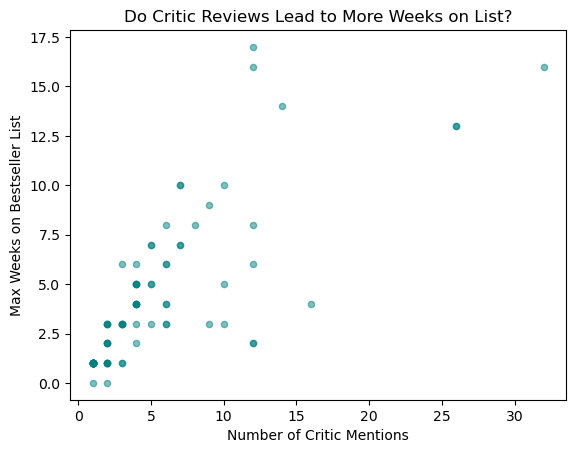

In [15]:
import matplotlib.pyplot as plt

df_analysis.plot(kind='scatter', x='review_count', y='max_weeks', 
                 title='Do Critic Reviews Lead to More Weeks on List?',
                 color='teal', alpha=0.5)
plt.xlabel('Number of Critic Mentions')
plt.ylabel('Max Weeks on Bestseller List')
plt.show()